# Multimodal House Price Prediction

Pipeline:
1. Load tabular data
2. Attach satellite image paths
3. Extract image embeddings using ResNet18
4. Merge image + tabular features
5. Train ML models (baseline)
6. Explain image importance using Grad-CAM

## 1. Imports & Setup

In [ ]:

import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO
import requests


## 2. Load Dataset

In [ ]:

fl = pd.read_csv(r'F:\CDC\SEMANTIC SEGMENTATION - Copy\training_tabular.csv').copy()
fl.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [ ]:
fl.drop(['date'] , axis = 1 , inplace = True)
fl["basement_ratio"] = fl["sqft_basement"] / (fl["sqft_living"] + 1)
fl.drop(columns=["sqft_above", "sqft_basement"], inplace=True)
fl["is_renovated"] = (fl["yr_renovated"] > 0).astype(int)
fl.drop(columns=["yr_renovated"], inplace=True)
fl["has_view"] = (fl["view"] > 0).astype(int)
fl["log_sqft_living"]=np.log1p(fl['sqft_living'])
fl["log_sqft_lot"] = np.log1p(fl["sqft_lot"])
fl["log_sqft_lot15"] = np.log1p(fl["sqft_lot15"])
fl["log_sqft_living15"] = np.log1p(fl["sqft_living15"])
zip_df = fl.groupby('zipcode').agg(np.mean)
zip_df.reset_index(inplace=True)
fl['count'] = 1
count_zip = fl.groupby('zipcode').sum()
count_zip.reset_index(inplace=True)
count_zip = count_zip[['zipcode', 'count']]
fl.drop(['count'], axis = 1, inplace=True)
zip_df = pd.merge(zip_df, count_zip, how='left', on=['zipcode'])
bins = [0, 3, 6, 7, 10, 13]
labels = [
    "Very Poor",
    "Below Average",
    "Average",
    "Good",
    "Excellent"
]

fl["grade_binned"] = pd.cut(
    fl["grade"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
grade_mapping = {
    "Very Poor": 1,
    "Below Average": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
}

fl["grade_binned_encoded"] = fl["grade_binned"].map(grade_mapping)

fl.drop(['grade_binned'], axis=1, inplace=True)
fl["living_vs_neighbors"] = fl["sqft_living"] / (fl["sqft_living15"] + 1)
fl["lot_vs_neighbors"] = fl["sqft_lot"] / (fl["sqft_lot15"] + 1)

C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_16824\3296733031.py:11: FutureWarning: The provided callable <function mean at 0x000001AC62237BE0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  zip_df = fl.groupby('zipcode').agg(np.mean)


In [ ]:
df['price']= np.log(df['price'])

In [ ]:
df1=fl.copy()


dum_feat = df1[['bedrooms', 'bathrooms', 'floors', 'condition', 'grade','zipcode']]
dum_index = dum_feat.columns
# To prevent what they call the dummy variable trap (related to multicollinearity), drop one of the dummy variable, as well as  the original categorical variable used in creating the dummy variables
df_dum = pd.get_dummies(data=dum_feat, columns=dum_index, drop_first=True, prefix=['bdr', 'bth',
 'flr', 'cnd', 'grd','zip'])

FEATURES = ['id',
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",'basement_ratio',
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15","sqft_living",
    'lat','price'
]



df = pd.concat(
    [fl[FEATURES], df_dum],
    axis=1)


In [ ]:
df.head()

,id,waterfront,has_view,living_vs_neighbors,lot_vs_neighbors,basement_ratio,is_renovated,zipcode,log_sqft_lot,log_sqft_lot15,...,zip_98146,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199
0,9117000170,0,0,1.089705,0.999892,0.000000,0,98055,9.131405,9.131405,...,False,False,False,False,False,False,False,False,False,False
1,6700390210,0,0,0.929692,0.773156,0.000000,0,98031,7.933438,8.190354,...,False,False,False,False,False,False,False,False,False,False
2,7212660540,0,0,0.919294,1.158530,0.000000,0,98003,9.064042,8.916774,...,False,False,False,False,False,False,False,False,False,False
3,8562780200,0,0,0.999194,0.938748,0.072522,0,98027,6.559615,6.621406,...,False,False,False,False,False,False,False,False,False,False
4,7760400350,0,0,0.804525,1.654609,0.000000,0,98042,9.499796,8.996157,...,False,False,False,False,False,False,False,False,False,False


## 3. Attach Image Paths

In [ ]:

df['image_path'] = df["id"].map(lambda i: f'satellite_images/{i}.png')
df_img = df[df['image_path'].apply(os.path.exists)].copy()

print('Images found:', len(df_img))


Images found: 5218


In [ ]:
df_img.head()

,id,waterfront,has_view,living_vs_neighbors,lot_vs_neighbors,basement_ratio,is_renovated,zipcode,log_sqft_lot,log_sqft_lot15,...,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199,image_path
0,9117000170,0,0,1.089705,0.999892,0.000000,0,98055,9.131405,9.131405,...,False,False,False,False,False,False,False,False,False,satellite_images/9117000170.png
1,6700390210,0,0,0.929692,0.773156,0.000000,0,98031,7.933438,8.190354,...,False,False,False,False,False,False,False,False,False,satellite_images/6700390210.png
2,7212660540,0,0,0.919294,1.158530,0.000000,0,98003,9.064042,8.916774,...,False,False,False,False,False,False,False,False,False,satellite_images/7212660540.png
3,8562780200,0,0,0.999194,0.938748,0.072522,0,98027,6.559615,6.621406,...,False,False,False,False,False,False,False,False,False,satellite_images/8562780200.png
4,7760400350,0,0,0.804525,1.654609,0.000000,0,98042,9.499796,8.996157,...,False,False,False,False,False,False,False,False,False,satellite_images/7760400350.png


## 4. Load Pretrained ResNet18 (Feature Extractor)

In [ ]:

import torch
import torch.nn as nn
from torchvision import models, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_feat = nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet_feat.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

## 5. Image Transform

In [ ]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## 6. Extract Image Embeddings

In [ ]:

from tqdm import tqdm

def extract_embedding(path):
    img = Image.open(path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = resnet_feat(img)
    return feat.squeeze().cpu().numpy()

embeddings = []
for p in tqdm(df_img['image_path']):
    embeddings.append(extract_embedding(p))

embeddings = np.vstack(embeddings)
print(embeddings.shape)


100%|██████████| 3034/3034 [04:43<00:00, 10.70it/s]

(3034, 512)


## 7. Merge Image + Tabular Features

In [ ]:

img_features = pd.DataFrame(
    embeddings,
    index=df_img.index,
    columns=[f'img_feat_{i}' for i in range(512)]
)

df_final = pd.concat([df_img.reset_index(drop=True), img_features.reset_index(drop=True)], axis=1)
df_final.head()


,id,waterfront,has_view,living_vs_neighbors,lot_vs_neighbors,basement_ratio,is_renovated,zipcode,log_sqft_lot,log_sqft_lot15,...,img_feat_502,img_feat_503,img_feat_504,img_feat_505,img_feat_506,img_feat_507,img_feat_508,img_feat_509,img_feat_510,img_feat_511
0,9117000170,0,0,1.089705,0.999892,0.000000,0,98055,9.131405,9.131405,...,1.349135,0.262192,0.169892,0.523026,0.013640,0.798086,0.971667,3.737819,0.105111,0.082992
1,6700390210,0,0,0.929692,0.773156,0.000000,0,98031,7.933438,8.190354,...,1.358754,1.274735,0.444918,1.053354,0.038121,1.913880,0.911094,5.443956,0.023809,1.038741
2,7212660540,0,0,0.919294,1.158530,0.000000,0,98003,9.064042,8.916774,...,0.331878,1.588202,0.556421,1.640275,0.050680,1.768715,0.294807,5.076725,0.591125,0.265418
3,8562780200,0,0,0.999194,0.938748,0.072522,0,98027,6.559615,6.621406,...,0.655173,1.190337,0.600679,0.842181,0.347360,4.186893,1.746587,2.961636,0.088142,0.005517
4,7760400350,0,0,0.804525,1.654609,0.000000,0,98042,9.499796,8.996157,...,0.357717,1.946193,0.298595,0.720543,0.769909,2.630170,1.482942,1.849952,0.000000,0.000000


## 8. Train/Test Split

In [ ]:
print(df.columns.tolist())


['id', 'waterfront', 'has_view', 'living_vs_neighbors', 'lot_vs_neighbors', 'basement_ratio', 'is_renovated', 'zipcode', 'log_sqft_lot', 'log_sqft_lot15', 'log_sqft_living15', 'sqft_living', 'lat', 'price', 'bdr_1', 'bdr_2', 'bdr_3', 'bdr_4', 'bdr_5', 'bdr_6', 'bdr_7', 'bdr_8', 'bdr_9', 'bdr_10', 'bdr_33', 'bth_0.5', 'bth_0.75', 'bth_1.0', 'bth_1.25', 'bth_1.5', 'bth_1.75', 'bth_2.0', 'bth_2.25', 'bth_2.5', 'bth_2.75', 'bth_3.0', 'bth_3.25', 'bth_3.5', 'bth_3.75', 'bth_4.0', 'bth_4.25', 'bth_4.5', 'bth_4.75', 'bth_5.0', 'bth_5.25', 'bth_5.5', 'bth_5.75', 'bth_6.0', 'bth_6.25', 'bth_6.5', 'bth_6.75', 'bth_7.75', 'bth_8.0', 'flr_1.5', 'flr_2.0', 'flr_2.5', 'flr_3.0', 'flr_3.5', 'cnd_2', 'cnd_3', 'cnd_4', 'cnd_5', 'grd_3', 'grd_4', 'grd_5', 'grd_6', 'grd_7', 'grd_8', 'grd_9', 'grd_10', 'grd_11', 'grd_12', 'grd_13', 'zip_98002', 'zip_98003', 'zip_98004', 'zip_98005', 'zip_98006', 'zip_98007', 'zip_98008', 'zip_98010', 'zip_98011', 'zip_98014', 'zip_98019', 'zip_98022', 'zip_98023', 'zip_98

In [ ]:

from sklearn.model_selection import train_test_split

#FEATURES = [c for c in df_final.columns if c.startswith('img_feat_')]

FEATURES = ["waterfront", "has_view", "living_vs_neighbors", "lot_vs_neighbors",'basement_ratio',
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15","sqft_living",
    'lat']

X = df_final.drop(['price','id','image_path'], axis=1)
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((2427, 652), (607, 652))

## 9. Baseline Model (Linear Regression)

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))


RMSE: 222289.29030179905
R2: 0.7577661247317439


## 10. Using other models (Resnet)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
# ---------------------------------------------------
# Model Zoo
# ---------------------------------------------------
import joblib



def train_and_compare_models(X_train, X_test, y_train, y_test):
    models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),

    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# ---------------------------------------------------
# Training + Evaluation
# ---------------------------------------------------

    results = []

    for name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        if name=="XGBoost":
            joblib.dump(model, "xgb_model_forimg&tab.pkl")


        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2 Score": r2
        })

    # ---------------------------------------------------
    # Results Table
    # ---------------------------------------------------

    results_df = pd.DataFrame(results).sort_values(
        by="RMSE"
    ).reset_index(drop=True)

    print(results_df)


In [ ]:
train_and_compare_models(X_train, X_test, y_train, y_test)

c:\Users\KISHORE S\anaconda3\envs\segmentation\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.787e+13, tolerance: 3.395e+10
  model = cd_fast.enet_coordinate_descent(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 132851
[LightGBM] [Info] Number of data points in the train set: 2427, number of used features: 611
[LightGBM] [Info] Start training from score 537380.282653
               Model           RMSE            MAE  R2 Score
0  Linear Regression  222289.290302  128547.685669  0.757766
1   Lasso Regression  222301.644072  128548.676968  0.757739
2   Ridge Regression  222681.914352  128205.533852  0.756910
3  Gradient Boosting  231384.090955  105164.055086  0.737539
4      Random Forest  255139.306451  119091.872229  0.680881
5           LightGBM  272615.612847  114519.916316  0.635666
6            XGBoost  275420.875084  109610.554688  0.628130
7      Decision Tree  277807.315147  140800.089288  0.621657
8      KNN Regressor  356232.963160  165045.591598  0.377892


## Grad-CAM (Explainability-for resnet)

In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms


In [ ]:
resnet_cam = models.resnet18(pretrained=True)
resnet_cam = resnet_cam.to(device)
resnet_cam.eval()

target_layer = resnet_cam.layer4

c:\Users\KISHORE S\anaconda3\envs\segmentation\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KISHORE S\anaconda3\envs\segmentation\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):

        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor):
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output.mean()
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze()

        # ✅ CORRECT PLACE FOR detach()
        cam = cam.detach().cpu().numpy()

        cam = cv2.resize(cam, (224, 224))
        cam = cam / (cam.max() + 1e-8)

        return cam


In [ ]:
def show_gradcam(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    target_layer = resnet_cam.layer4[-1].conv2

    gradcam = GradCAM(resnet_cam, target_layer)

    # ✅ generate() already returns NumPy CAM
    cam = gradcam.generate(img_tensor)

    img_np = np.array(img.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = np.uint8(0.6 * img_np + 0.4 * heatmap)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM Visualization")
    plt.show()


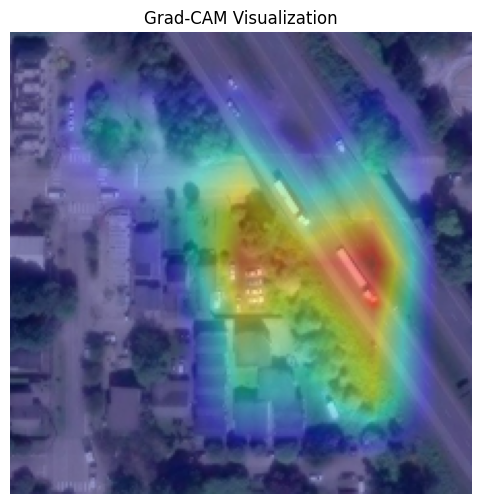

In [ ]:

show_gradcam(df_img["image_path"].iloc[2200])

## 11. using efficienNET B2 With PCA

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import numpy as np
import pandas as pd
import os

from sklearn.decomposition import PCA



In [ ]:
# ---------------------------------------------------
# EfficientNet-B2 backbone
# ---------------------------------------------------

efficientnet = models.efficientnet_b2(weights="IMAGENET1K_V1")
efficientnet = efficientnet.to(device)
efficientnet.eval()

# Remove classifier head
efficientnet.classifier = nn.Identity()

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\KISHORE S/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:01<00:00, 22.5MB/s]


In [ ]:
def extract_efficientnet_embedding(image_path, model):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(img_tensor)

    return features.squeeze().cpu().numpy()


In [ ]:
df_img

,id,waterfront,has_view,living_vs_neighbors,lot_vs_neighbors,basement_ratio,is_renovated,zipcode,log_sqft_lot,log_sqft_lot15,...,zip_98148,zip_98155,zip_98166,zip_98168,zip_98177,zip_98178,zip_98188,zip_98198,zip_98199,image_path
0,9117000170,0,0,1.089705,0.999892,0.000000,0,98055,9.131405,9.131405,...,False,False,False,False,False,False,False,False,False,satellite_images/9117000170.png
1,6700390210,0,0,0.929692,0.773156,0.000000,0,98031,7.933438,8.190354,...,False,False,False,False,False,False,False,False,False,satellite_images/6700390210.png
2,7212660540,0,0,0.919294,1.158530,0.000000,0,98003,9.064042,8.916774,...,False,False,False,False,False,False,False,False,False,satellite_images/7212660540.png
3,8562780200,0,0,0.999194,0.938748,0.072522,0,98027,6.559615,6.621406,...,False,False,False,False,False,False,False,False,False,satellite_images/8562780200.png
4,7760400350,0,0,0.804525,1.654609,0.000000,0,98042,9.499796,8.996157,...,False,False,False,False,False,False,False,False,False,satellite_images/7760400350.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15219,6300000226,0,0,1.061008,1.357724,0.000000,0,98133,7.683404,7.377134,...,False,False,False,False,False,False,False,False,False,satellite_images/6300000226.png
15482,6623400187,0,0,1.490262,0.855688,0.300965,0,98055,9.094593,9.250330,...,False,False,False,False,False,False,False,False,False,satellite_images/6623400187.png
15524,5132000140,0,0,1.341822,0.999803,0.182349,0,98106,8.533263,8.533263,...,False,False,False,False,False,False,False,False,False,satellite_images/5132000140.png
15618,726049190,0,0,0.999448,0.888779,0.375483,0,98133,8.881975,8.999743,...,False,False,False,False,False,False,False,False,False,satellite_images/726049190.png


In [ ]:
embeddings = []
indices = []

for idx in df_img['id']:
    img_path = f"satellite_images/{idx}.png"
    if not os.path.exists(img_path):
        continue

    emb = extract_efficientnet_embedding(img_path, efficientnet)
    embeddings.append(emb)
    indices.append(idx)

img_features = pd.DataFrame(
    embeddings,
    index=indices
)


In [ ]:
img_features

,0,1,2,3,4,5,6,7,8,9,...,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407
9117000170,0.022669,-0.030763,-0.024442,0.122804,-0.005915,-0.189371,-0.123016,0.050144,0.000409,-0.211374,...,-0.112656,-0.114798,-0.174284,0.791881,0.222513,-0.189479,-0.190889,0.049671,-0.107598,0.119772
6700390210,-0.065504,-0.181772,0.008634,0.481797,-0.133686,-0.180897,-0.180488,0.005366,0.084060,-0.150830,...,-0.124922,-0.219178,-0.171231,0.064519,0.198171,-0.215234,0.078390,0.071202,-0.106282,0.029534
7212660540,-0.176489,-0.175125,0.100763,0.090543,0.051905,-0.199479,-0.231154,0.364545,0.220795,-0.141969,...,-0.053235,-0.185396,-0.137987,0.236630,-0.002779,-0.163907,0.470472,0.196216,0.698090,-0.242335
8562780200,-0.201896,-0.185263,0.210660,0.237296,-0.191891,-0.139563,0.144625,0.168632,0.006547,-0.187704,...,-0.186692,0.280095,-0.178188,0.453825,0.076881,0.162861,-0.095364,-0.077426,-0.186634,0.180074
7760400350,-0.107736,-0.113403,-0.011556,0.098987,-0.000824,-0.201064,-0.143562,-0.174982,0.145373,-0.181136,...,0.032014,0.022475,-0.086125,0.947742,0.090352,0.727639,-0.093927,0.102065,0.039765,-0.220393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300000226,-0.077461,0.057397,0.196440,0.305200,-0.141413,-0.043214,-0.094129,0.005312,-0.119433,-0.206742,...,-0.128840,-0.171614,-0.155544,0.634752,0.012867,0.016077,-0.206256,0.249836,0.131880,0.526147
6623400187,-0.036950,-0.212015,0.012760,0.341684,0.269035,-0.067273,-0.202171,-0.090600,-0.153346,-0.127447,...,-0.164380,-0.149117,-0.069044,0.284343,0.028662,-0.121562,-0.184588,-0.003768,-0.157631,-0.094989
5132000140,0.140984,-0.229684,-0.215420,0.169968,-0.216641,-0.118158,-0.058313,0.027194,0.071395,-0.179861,...,-0.018341,-0.068580,-0.120559,0.154411,-0.015489,-0.178291,-0.160033,0.220284,0.188519,0.059270
726049190,0.060013,-0.006507,0.019909,0.454686,-0.151815,-0.196455,-0.178408,-0.090135,0.021758,-0.177263,...,-0.069358,-0.178561,-0.198015,0.396408,0.020146,-0.077966,-0.153652,0.090710,0.049847,-0.179281


In [ ]:
pca = PCA(n_components=64, random_state=42)
img_features_pca = pca.fit_transform(img_features)
img_features_pca.shape

(5218, 64)

In [ ]:
df_effec= df_img.copy()
df_effec.drop(columns=['image_path'], inplace=True)

img_features_pca_df = pd.DataFrame(
    img_features_pca,
    index=img_features.index,              # ✅ preserve id alignment
    columns=[f"img_pca_{i}" for i in range(64)]
)

df_effec = df_effec.set_index("id")
df_effec = df_effec.join(img_features_pca_df, how="left")
df_effec = df_effec.reset_index()

df_effec[img_features_pca_df.columns] = (
    df_effec[img_features_pca_df.columns].fillna(0)
)



In [ ]:
df_effec

,id,waterfront,has_view,living_vs_neighbors,lot_vs_neighbors,basement_ratio,is_renovated,zipcode,log_sqft_lot,log_sqft_lot15,...,img_pca_54,img_pca_55,img_pca_56,img_pca_57,img_pca_58,img_pca_59,img_pca_60,img_pca_61,img_pca_62,img_pca_63
0,9117000170,0,0,1.089705,0.999892,0.000000,0,98055,9.131405,9.131405,...,0.316053,-0.520618,0.362587,-0.227401,-0.272660,-0.418036,-0.053811,0.074856,0.193634,0.162602
1,6700390210,0,0,0.929692,0.773156,0.000000,0,98031,7.933438,8.190354,...,0.329439,0.154347,-0.716488,-0.486024,0.164948,0.105343,0.505296,0.134721,0.009309,0.293453
2,7212660540,0,0,0.919294,1.158530,0.000000,0,98003,9.064042,8.916774,...,0.126631,0.027446,-0.730305,-0.868061,0.257010,-0.455091,0.415658,1.218044,0.146813,-0.531316
3,8562780200,0,0,0.999194,0.938748,0.072522,0,98027,6.559615,6.621406,...,-0.423265,0.907714,-0.166059,0.386055,0.395451,0.089970,0.318284,-0.322898,0.684548,0.750891
4,7760400350,0,0,0.804525,1.654609,0.000000,0,98042,9.499796,8.996157,...,-0.046900,0.458195,-0.150294,0.256252,-0.590552,-0.168478,0.612291,-0.143937,-0.008951,-0.075992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5331,5132000140,0,0,1.341822,0.999803,0.182349,0,98106,8.533263,8.533263,...,-0.717784,-0.475848,-0.567199,-0.608752,0.657326,0.718035,0.233801,-0.108082,-0.215424,-0.121941
5332,726049190,0,0,0.999448,0.888779,0.375483,0,98133,8.881975,8.999743,...,-0.731590,-0.035418,0.172149,0.378546,-0.592657,0.012548,-0.026314,-0.677976,0.369448,0.392077
5333,726049190,0,0,0.999448,0.888779,0.375483,0,98133,8.881975,8.999743,...,-0.731590,-0.035417,0.172149,0.378546,-0.592657,0.012548,-0.026314,-0.677977,0.369448,0.392077
5334,1954420170,0,0,0.999535,1.087791,0.000000,0,98074,8.920656,8.836374,...,-1.301913,0.223293,-0.597067,0.596169,-0.409659,0.135347,1.696005,-0.193475,-0.337546,-0.339241


In [ ]:
X = df_effec.drop(['price','id'], axis=1)
y = df_effec['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((4268, 204), (1068, 204))

In [ ]:
train_and_compare_models(X_train, X_test, y_train, y_test)

c:\Users\KISHORE S\anaconda3\envs\segmentation\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.704e+13, tolerance: 6.139e+10
  model = cd_fast.enet_coordinate_descent(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18633
[LightGBM] [Info] Number of data points in the train set: 4268, number of used features: 174
[LightGBM] [Info] Start training from score 533787.894330
               Model           RMSE            MAE  R2 Score
0  Gradient Boosting  158951.895652   90057.809516  0.845736
1   Lasso Regression  179757.633151   93865.900395  0.802709
2  Linear Regression  179757.910786   93865.868020  0.802708
3   Ridge Regression  179816.434375   93844.213958  0.802580
4            XGBoost  188701.577058   82530.906250  0.782588
5      Random Forest  190402.190051   96816.620328  0.778651
6           LightGBM  199360.631564   90018.889348  0.757332
7      Decision Tree  221325.601325  119966.138899  0.700914
8      KNN Regressor  269503.424397  120907.805524  0.556533


## GradCam for efficientnet

In [ ]:
from torchvision import models
import torch.nn as nn

efficientnet_cam = models.efficientnet_b2(
    weights="IMAGENET1K_V1"
).to(device)

efficientnet_cam.eval()

def show_gradcam_efficientnet(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    # 🔑 EfficientNet target layer
    target_layer = efficientnet_cam.features[-1]

    gradcam = GradCAM(efficientnet_cam, target_layer)

    cam = gradcam.generate(img_tensor)

    img_np = np.array(img.resize((224, 224)))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = np.uint8(0.6 * img_np + 0.4 * heatmap)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("EfficientNet Grad-CAM")
    plt.show()


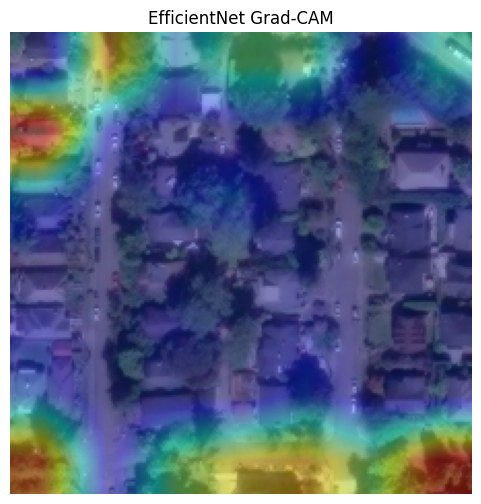

In [ ]:

show_gradcam_efficientnet(df_img["image_path"].iloc[4000])

## 12. Prediction on testing data

In [ ]:
tfl = pd.read_csv(r'F:\CDC\SEMANTIC SEGMENTATION - Copy\training_tabular.csv').copy()



tfl.drop(['date'] , axis = 1 , inplace = True)
tfl["basement_ratio"] = tfl["sqft_basement"] / (tfl["sqft_living"] + 1)
tfl.drop(columns=["sqft_above", "sqft_basement"], inplace=True)
tfl["is_renovated"] = (tfl["yr_renovated"] > 0).astype(int)
tfl.drop(columns=["yr_renovated"], inplace=True)
tfl["has_view"] = (tfl["view"] > 0).astype(int)
tfl["log_sqft_living"]=np.log1p(tfl['sqft_living'])
tfl["log_sqft_lot"] = np.log1p(tfl["sqft_lot"])
tfl["log_sqft_lot15"] = np.log1p(tfl["sqft_lot15"])
tfl["log_sqft_living15"] = np.log1p(tfl["sqft_living15"])
zip_df = tfl.groupby('zipcode').agg(np.mean)
zip_df.reset_index(inplace=True)
tfl['count'] = 1
count_zip = tfl.groupby('zipcode').sum()
count_zip.reset_index(inplace=True)
count_zip = count_zip[['zipcode', 'count']]
tfl.drop(['count'], axis = 1, inplace=True)
zip_df = pd.merge(zip_df, count_zip, how='left', on=['zipcode'])
bins = [0, 3, 6, 7, 10, 13]
labels = [
    "Very Poor",
    "Below Average",
    "Average",
    "Good",
    "Excellent"
]

tfl["grade_binned"] = pd.cut(
    tfl["grade"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
grade_mapping = {
    "Very Poor": 1,
    "Below Average": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
}

tfl["grade_binned_encoded"] = tfl["grade_binned"].map(grade_mapping)

tfl.drop(['grade_binned'], axis=1, inplace=True)
tfl["living_vs_neighbors"] = tfl["sqft_living"] / (tfl["sqft_living15"] + 1)
tfl["lot_vs_neighbors"] = tfl["sqft_lot"] / (tfl["sqft_lot15"] + 1)

tfl['price']= np.log(tfl['price'])

df1=tfl.copy()


dum_feat = df1[['bedrooms', 'bathrooms', 'floors', 'condition', 'grade','zipcode']]
dum_index = dum_feat.columns
# To prevent what they call the dummy variable trap (related to multicollinearity), drop one of the dummy variable, as well as  the original categorical variable used in creating the dummy variables
df_dum = pd.get_dummies(data=dum_feat, columns=dum_index, drop_first=True, prefix=['bdr', 'bth',
 'flr', 'cnd', 'grd','zip'])

FEATURES = ['id',
    "waterfront", "has_view",
    "living_vs_neighbors", "lot_vs_neighbors",'basement_ratio',
    "is_renovated","zipcode", "log_sqft_lot", "log_sqft_lot15", "log_sqft_living15","sqft_living",
    'lat','price'
]



tdf = pd.concat(
    [df1[FEATURES], df_dum],
    axis=1)





tdf['image_path'] = tdf["id"].map(lambda i: f'satellite_images_test/{i}.png')
tdf_img = tdf[tdf['image_path'].apply(os.path.exists)].copy()

print('Images found:', len(tdf_img))


In [ ]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
embeddings = []
indices = []

for idx in tdf_img['id']:
    img_path = f"satellite_images_test/{idx}.png"
    if not os.path.exists(img_path):
        continue

    emb = extract_efficientnet_embedding(img_path, efficientnet)
    embeddings.append(emb)
    indices.append(idx)

img_features = pd.DataFrame(
    embeddings,
    index=indices
)

pca = PCA(n_components=64, random_state=42)
timg_features_pca = pca.fit_transform(img_features)

tdf_effec= df_img.copy()
tdf_effec.drop(columns=['image_path'], inplace=True)

img_features_pca_df = pd.DataFrame(
    img_features_pca,
    index=img_features.index,              # ✅ preserve id alignment
    columns=[f"img_pca_{i}" for i in range(64)]
)

tdf_effec = tdf_effec.set_index("id")
tdf_effec = tdf_effec.join(img_features_pca_df, how="left")
tdf_effec = tdf_effec.reset_index()

tdf_effec[img_features_pca_df.columns] = (
    tdf_effec[img_features_pca_df.columns].fillna(0)
)


In [ ]:
X = df_effec.drop(['price','id'], axis=1)
y = df_effec['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

In [ ]:
xgb_model_img = joblib.load("xgb_model_img.pkl")

In [ ]:
log_price_pred = xgb_model_img.predict(X)
price_pred = np.expm1(log_price_pred)

In [ ]:
submission = pd.DataFrame({
    "id": file_path["id"],
    "price": price_pred
})

submission.to_csv("predicted_tab&img.csv", index=False)

print("✅ Predictions saved to predicted_tab&img.csv")